# Bike Sharing Demand - Regression

**Goal:** predict the hourly number of bike rentals (`count`) from weather and calendar info.
**Dataset:** Kaggle Bike Sharing Demand (`train.csv`) - hourly records from a bike rental system, 2011-2012.
**Approach:** explore the data, engineer time features, compare 4 regression models, save the best one and build a small prediction widget.

In [1]:
import zipfile

zip_path = "/content/bike-sharing-demand.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/bike_data")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [2]:
import os

print(os.listdir("/content/bike_data"))

['train.csv', 'sampleSubmission.csv', 'test.csv']


## 1. Data Loading
`train.csv` has 10,886 hourly rows and 12 columns: `datetime`, `season`, `holiday`, `workingday`, `weather`, `temp`, `atemp`, `humidity`, `windspeed`, plus `casual`, `registered` and the target `count` (`casual` + `registered`).

In [3]:
import pandas as pd

df = pd.read_csv("/content/bike_data/train.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


## 2. Data Inspection & Cleaning
Checking data types, missing values, duplicates and basic statistics. Result: no missing values and no duplicate rows, so no rows needed to be dropped or filled.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


In [6]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [7]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


## 3. EDA
Looking at the target and what drives it:
- **Distribution of `count`:** right-skewed - most hours have low/moderate demand, a few have very high demand.
- **By hour:** clear commute-time peaks (morning and evening) - hour matters a lot.
- **By season/weather:** demand is lowest in spring (season 1) and drops in bad weather.
- **Correlations:** `hour` and `temp` correlate positively with count, `humidity` negatively.

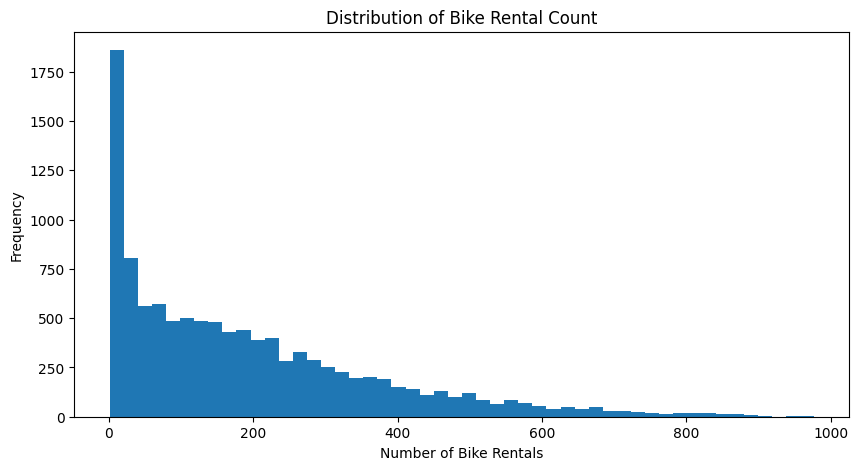

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["count"], bins=50)
plt.xlabel("Number of Bike Rentals")
plt.ylabel("Frequency")
plt.title("Distribution of Bike Rental Count")
plt.show()

In [9]:
df["datetime"] = pd.to_datetime(df["datetime"])

print(df["datetime"].dtype)
print("Start:", df["datetime"].min())
print("End:", df["datetime"].max())

datetime64[ns]
Start: 2011-01-01 00:00:00
End: 2012-12-19 23:00:00


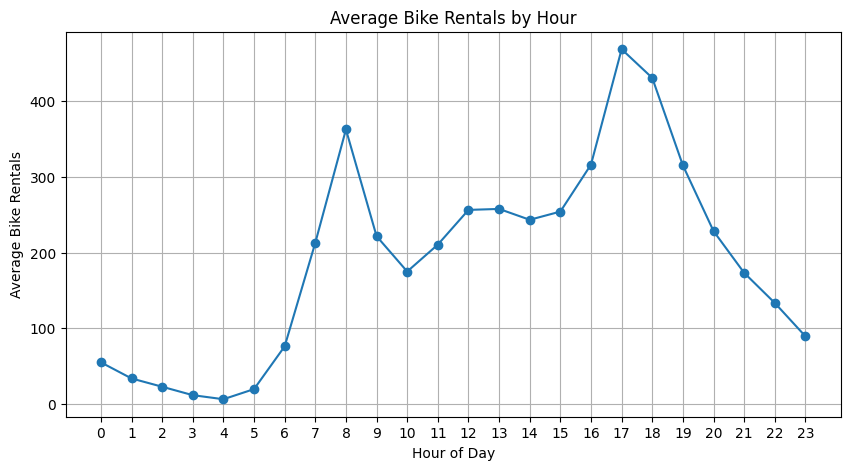

In [10]:
df["hour"] = df["datetime"].dt.hour

hourly_demand = df.groupby("hour")["count"].mean()

plt.figure(figsize=(10, 5))
plt.plot(hourly_demand.index, hourly_demand.values, marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Average Bike Rentals")
plt.title("Average Bike Rentals by Hour")
plt.xticks(range(24))
plt.grid()
plt.show()

In [11]:
workingday_demand = df.groupby("workingday")["count"].mean()

print(workingday_demand)

workingday
0    188.506621
1    193.011873
Name: count, dtype: float64


In [12]:
season_demand = df.groupby("season")["count"].mean()

print(season_demand)

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: count, dtype: float64


In [13]:
weather_demand = df.groupby("weather")["count"].mean()

print(weather_demand)

weather
1    205.236791
2    178.955540
3    118.846333
4    164.000000
Name: count, dtype: float64


In [14]:
correlation = df.select_dtypes(include="number").corr()

print(correlation["count"].sort_values(ascending=False))

count         1.000000
registered    0.970948
casual        0.690414
hour          0.400601
temp          0.394454
atemp         0.389784
season        0.163439
windspeed     0.101369
workingday    0.011594
holiday      -0.005393
weather      -0.128655
humidity     -0.317371
Name: count, dtype: float64


**Outlier check:** boxplots show high values in `count`, `casual` and `registered`. These were kept because they are real busy hours (rush hour, good weather), not data errors - and tree models handle them fine.

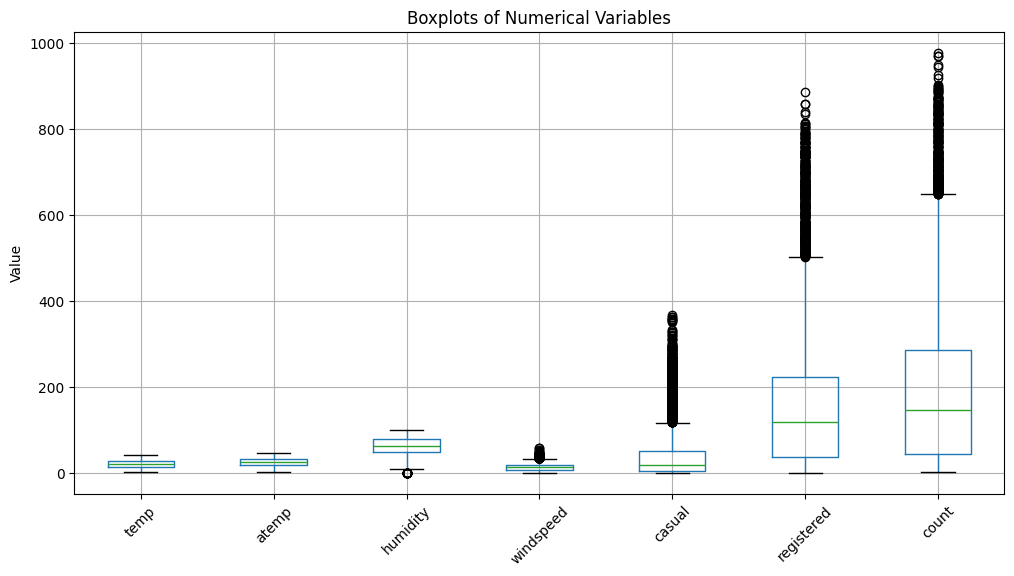

In [15]:
numeric_columns = [
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "casual",
    "registered",
    "count"
]

plt.figure(figsize=(12, 6))
df[numeric_columns].boxplot()
plt.title("Boxplots of Numerical Variables")
plt.xticks(rotation=45)
plt.ylabel("Value")
plt.show()

## 4. Feature Engineering
The raw `datetime` column can't be used directly by a model, so it is split into `year`, `month`, `day`, `hour` and `dayofweek`. This lets the model learn daily, weekly and yearly patterns (e.g. rush hours, weekends, growth from 2011 to 2012).

In [16]:
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["dayofweek"] = df["datetime"].dt.dayofweek

print("New features created:")
print(["year", "month", "day", "hour", "dayofweek"])

display(df[["datetime", "year", "month", "day", "hour", "dayofweek"]].head())

New features created:
['year', 'month', 'day', 'hour', 'dayofweek']


,datetime,year,month,day,hour,dayofweek
0,2011-01-01 00:00:00,2011,1,1,0,5
1,2011-01-01 01:00:00,2011,1,1,1,5
2,2011-01-01 02:00:00,2011,1,1,2,5
3,2011-01-01 03:00:00,2011,1,1,3,5
4,2011-01-01 04:00:00,2011,1,1,4,5


**Feature selection:** 12 features are used (weather, calendar and time features). `casual` and `registered` are left out on purpose - they add up to `count`, so using them would leak the answer. `day` is created during feature engineering but not used as a model input.

In [17]:
features = [
    "season",
    "holiday",
    "workingday",
    "weather",
    "temp",
    "atemp",
    "humidity",
    "windspeed",
    "year",
    "month",
    "hour",
    "dayofweek"
]

X = df[features]
y = df["count"]

print("Features used for prediction:")
print(features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used for prediction:
['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'dayofweek']

X shape: (10886, 12)
y shape: (10886,)


## 5. Train / Validation Split
Time-based split: first 80% of the data for training, last 20% for validation (no shuffling). This mimics real use - predicting the future from the past - and avoids leaking future information into training.

In [18]:
# Use the first 80% of the data for training
# and the last 20% for validation

split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_val = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_val = y.iloc[split_index:]

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_val.shape)

print("\nTraining period:")
print(df["datetime"].iloc[0], "to", df["datetime"].iloc[split_index - 1])

print("\nValidation period:")
print(df["datetime"].iloc[split_index], "to", df["datetime"].iloc[-1])

Training set: (8708, 12)
Validation set: (2178, 12)
Training target: (8708,)
Validation target: (2178,)

Training period:
2011-01-01 00:00:00 to 2012-08-05 04:00:00

Validation period:
2012-08-05 05:00:00 to 2012-12-19 23:00:00


## 6. Scaling
`StandardScaler` is fit on the training data only, then applied to validation (avoids leakage). Scaling is used for Linear Regression; the tree-based models don't need it.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Training data after scaling:", X_train_scaled.shape)
print("Validation data after scaling:", X_val_scaled.shape)

Training data after scaling: (8708, 12)
Validation data after scaling: (2178, 12)


## 7. Model Training & Comparison
Four experiments, evaluated with MAE, RMSE, R² and RMSLE (RMSLE fits this problem since demand is skewed).

**Model 1 - Linear Regression (baseline):** simple and fast, but assumes a straight-line relationship.

In [20]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_val_scaled)

print("Linear Regression trained successfully!")

Linear Regression trained successfully!


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_val, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_val, y_pred_linear))
r2_linear = r2_score(y_val, y_pred_linear)

# RMSLE requires non-negative predictions
y_pred_linear_nonnegative = np.maximum(y_pred_linear, 0)

rmsle_linear = np.sqrt(
    mean_squared_error(
        np.log1p(y_val),
        np.log1p(y_pred_linear_nonnegative)
    )
)

print("Linear Regression Results")
print("-------------------------")
print("MAE   :", mae_linear)
print("RMSE  :", rmse_linear)
print("R²    :", r2_linear)
print("RMSLE :", rmsle_linear)

Linear Regression Results
-------------------------
MAE   : 141.3862624318465
RMSE  : 184.0386351472989
R²    : 0.28465973076473816
RMSLE : 1.241015548894179


**Model 2 - Random Forest (200 trees):** handles non-linear patterns and feature interactions (like hour x workingday) without scaling.

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
r2_rf = r2_score(y_val, y_pred_rf)

# RMSLE requires non-negative predictions
y_pred_rf_nonnegative = np.maximum(y_pred_rf, 0)

rmsle_rf = np.sqrt(
    mean_squared_error(
        np.log1p(y_val),
        np.log1p(y_pred_rf_nonnegative)
    )
)

print("Random Forest Results")
print("---------------------")
print("MAE   :", mae_rf)
print("RMSE  :", rmse_rf)
print("R²    :", r2_rf)
print("RMSLE :", rmsle_rf)

Random Forest Results
---------------------
MAE   : 46.135758690804145
RMSE  : 72.10842202250885
R²    : 0.8901837397671347
RMSLE : 0.3424515036246527


**Model 3 - Gradient Boosting (200 trees, lr=0.05, depth=5):** builds trees one after another, each fixing the errors of the previous ones.

In [24]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_val)

print("Gradient Boosting trained successfully!")

Gradient Boosting trained successfully!


In [25]:
mae_gb = mean_absolute_error(y_val, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_val, y_pred_gb))
r2_gb = r2_score(y_val, y_pred_gb)

# RMSLE requires non-negative predictions
y_pred_gb_nonnegative = np.maximum(y_pred_gb, 0)

rmsle_gb = np.sqrt(
    mean_squared_error(
        np.log1p(y_val),
        np.log1p(y_pred_gb_nonnegative)
    )
)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE   :", mae_gb)
print("RMSE  :", rmse_gb)
print("R²    :", r2_gb)
print("RMSLE :", rmsle_gb)

Gradient Boosting Results
-------------------------
MAE   : 46.62409711958004
RMSE  : 70.88203894078747
R²    : 0.8938873722383238
RMSLE : 0.41903038432682577


**Model 4 - Random Forest with log-transformed target:** trains on `log1p(count)` to reduce the skew, then converts predictions back. Tested to see if it helps - it did not (worse MAE/RMSE/R² than the plain Random Forest).

In [26]:
# Transform the target using log1p
y_train_log = np.log1p(y_train)

rf_log_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_log_model.fit(X_train, y_train_log)

# Predict in log space
y_pred_rf_log = rf_log_model.predict(X_val)

# Convert predictions back to the original count scale
y_pred_rf_log_original = np.expm1(y_pred_rf_log)

# Make sure predictions are not negative
y_pred_rf_log_original = np.maximum(y_pred_rf_log_original, 0)

print("Log-target Random Forest trained successfully!")

Log-target Random Forest trained successfully!


In [27]:
mae_rf_log = mean_absolute_error(y_val, y_pred_rf_log_original)
rmse_rf_log = np.sqrt(mean_squared_error(y_val, y_pred_rf_log_original))
r2_rf_log = r2_score(y_val, y_pred_rf_log_original)

rmsle_rf_log = np.sqrt(
    mean_squared_error(
        np.log1p(y_val),
        np.log1p(y_pred_rf_log_original)
    )
)

print("Log-target Random Forest Results")
print("--------------------------------")
print("MAE   :", mae_rf_log)
print("RMSE  :", rmse_rf_log)
print("R²    :", r2_rf_log)
print("RMSLE :", rmsle_rf_log)

Log-target Random Forest Results
--------------------------------
MAE   : 54.80571301008209
RMSE  : 86.34802073591662
R²    : 0.8425294151507804
RMSLE : 0.3747569414543359


## 8. Feature Importance
`hour` is by far the most important feature (~59%), followed by `atemp`, `year` and `temp`. This matches the EDA - time of day drives demand the most.

In [28]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

       Feature  Importance
10        hour    0.593100
5        atemp    0.110206
8         year    0.068744
4         temp    0.055156
11   dayofweek    0.043559
2   workingday    0.036330
6     humidity    0.031316
9        month    0.027794
3      weather    0.015594
7    windspeed    0.010284
0       season    0.005555
1      holiday    0.002361


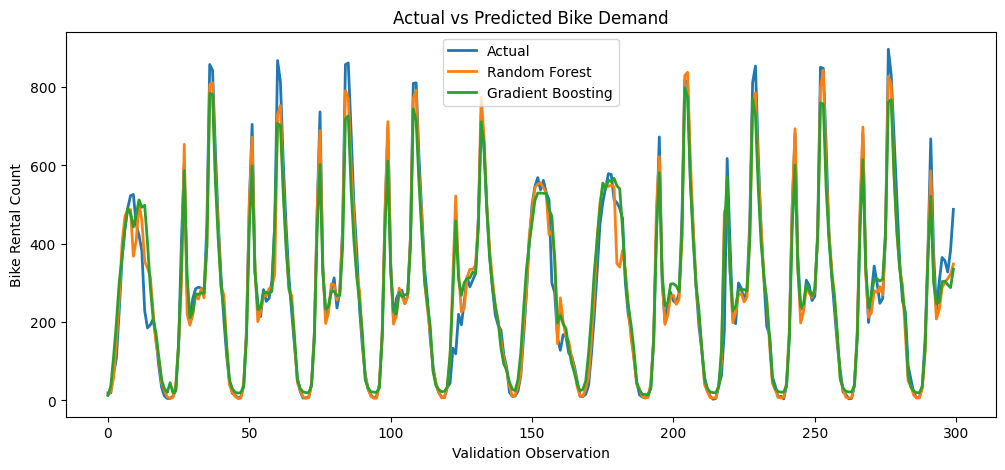

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    y_val.values[:300],
    label="Actual",
    linewidth=2
)

plt.plot(
    y_pred_rf[:300],
    label="Random Forest",
    linewidth=2
)

plt.plot(
    y_pred_gb[:300],
    label="Gradient Boosting",
    linewidth=2
)

plt.title("Actual vs Predicted Bike Demand")
plt.xlabel("Validation Observation")
plt.ylabel("Bike Rental Count")
plt.legend()
plt.show()

## 9. Results Summary
- **Linear Regression** performs poorly (R² = 0.285) - the relationship is clearly non-linear.
- **Random Forest** and **Gradient Boosting** are far better (R² about 0.89) and very close to each other.
- **Log-target RF** is slightly worse than the plain RF.

Random Forest has the best MAE (46.14) and RMSLE (0.342), so it is chosen as the final model.

In [30]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Random Forest + Log Target"
    ],
    "MAE": [
        141.39,
        46.14,
        46.62,
        54.82
    ],
    "RMSE": [
        184.04,
        72.11,
        70.88,
        86.33
    ],
    "R2": [
        0.285,
        0.890,
        0.894,
        0.843
    ],
    "RMSLE": [
        1.241,
        0.342,
        0.419,
        0.375
    ]
})

results


,Model,MAE,RMSE,R2,RMSLE
0,Linear Regression,141.39,184.04,0.285,1.241
1,Random Forest,46.14,72.11,0.890,0.342
2,Gradient Boosting,46.62,70.88,0.894,0.419
3,Random Forest + Log Target,54.82,86.33,0.843,0.375


## 10. Final Model & Saving
The chosen Random Forest is retrained on all available data (train + validation) and saved with `joblib`, together with the feature list so the same columns are used at prediction time.

In [31]:
# Train the final Random Forest model using all available training data

from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

print("Final model trained successfully!")
print("Training data:", X.shape)


Final model trained successfully!
Training data: (10886, 12)


In [32]:
import joblib

joblib.dump(final_model, "/content/final_bike_demand_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [33]:
model_info = {
    "model": final_model,
    "features": features
}

joblib.dump(model_info, "/content/final_bike_demand_model_with_features.pkl")

print("Model and feature information saved successfully!")
print("Features:", features)

Model and feature information saved successfully!
Features: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'dayofweek']


## 11. Loading the Saved Model
Reloading the saved file to confirm the model and its 12 features work correctly.

In [34]:
# Load the saved model

loaded_model_info = joblib.load(
    "/content/final_bike_demand_model_with_features.pkl"
)

loaded_model = loaded_model_info["model"]
loaded_features = loaded_model_info["features"]

print("Saved model loaded successfully!")
print("Number of features:", len(loaded_features))
print("Features:", loaded_features)

Saved model loaded successfully!
Number of features: 12
Features: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'year', 'month', 'hour', 'dayofweek']


## 12. Working Prototype
A simple interactive widget: pick the season, weather, temperature, hour, etc., click **Predict Bike Demand**, and the saved model returns the expected number of rentals.

In [35]:
import ipywidgets as widgets
from IPython.display import display

# Input widgets

season_input = widgets.Dropdown(
    options=[1, 2, 3, 4],
    value=1,
    description="Season:"
)

holiday_input = widgets.Dropdown(
    options=[0, 1],
    value=0,
    description="Holiday:"
)

workingday_input = widgets.Dropdown(
    options=[0, 1],
    value=1,
    description="Working day:"
)

weather_input = widgets.Dropdown(
    options=[1, 2, 3, 4],
    value=1,
    description="Weather:"
)

temp_input = widgets.FloatSlider(
    value=20,
    min=0,
    max=40,
    step=0.1,
    description="Temp:"
)

atemp_input = widgets.FloatSlider(
    value=20,
    min=0,
    max=45,
    step=0.1,
    description="Feels temp:"
)

humidity_input = widgets.IntSlider(
    value=60,
    min=0,
    max=100,
    step=1,
    description="Humidity:"
)

windspeed_input = widgets.FloatSlider(
    value=10,
    min=0,
    max=60,
    step=0.1,
    description="Windspeed:"
)

year_input = widgets.Dropdown(
    options=[2011, 2012],
    value=2012,
    description="Year:"
)

month_input = widgets.IntSlider(
    value=6,
    min=1,
    max=12,
    step=1,
    description="Month:"
)

hour_input = widgets.IntSlider(
    value=17,
    min=0,
    max=23,
    step=1,
    description="Hour:"
)

dayofweek_input = widgets.IntSlider(
    value=1,
    min=0,
    max=6,
    step=1,
    description="Day of week:"
)

display(
    season_input,
    holiday_input,
    workingday_input,
    weather_input,
    temp_input,
    atemp_input,
    humidity_input,
    windspeed_input,
    year_input,
    month_input,
    hour_input,
    dayofweek_input
)

Dropdown(description='Season:', options=(1, 2, 3, 4), value=1)

Dropdown(description='Holiday:', options=(0, 1), value=0)

Dropdown(description='Working day:', index=1, options=(0, 1), value=1)

Dropdown(description='Weather:', options=(1, 2, 3, 4), value=1)

FloatSlider(value=20.0, description='Temp:', max=40.0)

...

FloatSlider(value=10.0, description='Windspeed:', max=60.0)

Dropdown(description='Year:', index=1, options=(2011, 2012), value=2012)

IntSlider(value=6, description='Month:', max=12, min=1)

IntSlider(value=17, description='Hour:', max=23)

IntSlider(value=1, description='Day of week:', max=6)

In [36]:
predict_button = widgets.Button(
    description="Predict Bike Demand",
    button_style="primary"
)

output = widgets.Output()

def predict_demand(b):
    with output:
        output.clear_output()

        input_data = pd.DataFrame([{
            "season": season_input.value,
            "holiday": holiday_input.value,
            "workingday": workingday_input.value,
            "weather": weather_input.value,
            "temp": temp_input.value,
            "atemp": atemp_input.value,
            "humidity": humidity_input.value,
            "windspeed": windspeed_input.value,
            "year": year_input.value,
            "month": month_input.value,
            "hour": hour_input.value,
            "dayofweek": dayofweek_input.value
        }])

        prediction = loaded_model.predict(input_data)[0]

        print(f"Predicted bike rentals: {prediction:.0f}")

predict_button.on_click(predict_demand)

display(predict_button, output)

Button(button_style='primary', description='Predict Bike Demand', style=ButtonStyle())

Output()

## 13. Model File Size
The saved Random Forest is large (179 MB; 89 MB with 100 trees), too big for a normal GitHub upload. Host it externally (e.g. Hugging Face / Google Drive) and link it in the README.

In [37]:
import os

model_path = "/content/final_bike_demand_model_with_features.pkl"

size_mb = os.path.getsize(model_path) / (1024 * 1024)

print(f"Model file size: {size_mb:.2f} MB")
print(f"Model file exists: {os.path.exists(model_path)}")

Model file size: 179.08 MB
Model file exists: True


In [38]:
from sklearn.ensemble import RandomForestRegressor
import joblib
import os

small_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

small_model.fit(X, y)

small_model_path = "/content/small_bike_model.pkl"
joblib.dump(small_model, small_model_path)

size_mb = os.path.getsize(small_model_path) / (1024 * 1024)

print(f"Smaller model size: {size_mb:.2f} MB")

Smaller model size: 89.57 MB
